# Tools for getting the ROI

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog

from skimage import measure
from skimage import morphology

In [35]:
def get_rect(image,k = 0):

    imgray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    (thresh, im_bw) = cv2.threshold(imgray, 90, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    #im_bw= cv2.adaptiveThreshold(imgray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY, 11, 2)
    im_bw = np.array(255-im_bw, dtype=bool)
    cleaned = morphology.remove_small_objects(im_bw, min_size=20, connectivity=2)
    cleaned = np.array(cleaned, dtype=int)
    cleaned = 255+cleaned
    label, n = measure.label(cleaned, background=255, return_num=True, connectivity=2)
    print("number of numbers on image : ",n)
    x = []
    y = []
    numbers = []
    ph=[]
    rect=[]
    for i in range(1, n + 1):
        for r in range(label.shape[0]):
            for c in range(label.shape[1]):
                if label[r, c] == i:
                    x.append(r)
                    y.append(c)

        digit = im_bw[min(x): max(x), min(y): max(y)]

        rect.append([(min(y), min(x)), (max(y) - min(y)), (max(x) - min(x))])
        padd_y = 0
        padding = np.zeros([digit.shape[0]+padd_y, digit.shape[1] + k], dtype='float64')
        padding[padd_y//2:padding.shape[0]-padd_y//2, k//2:padding.shape[1] - k//2] = digit
        ph.append(padding)

        re_digit= cv2.resize(np.array(padding,dtype='float64'), (28, 28), interpolation=cv2.INTER_AREA)
        re_digit = cv2.dilate(re_digit, (3, 3))
        # Calculate the HOG features
        roi_hog_fd = hog(re_digit, orientations=9, pixels_per_cell=(14, 14), cells_per_block=(1, 1), visualize=False)

        numbers.append( np.array([roi_hog_fd], 'float64'))
        x = []
        y = []

    return rect

Testing

In [33]:
image_path =  "73.png"
image = cv2.imread(image_path)
rect = get_rect(image)

number of numbers on image :  2


In [9]:
rect

[[(23, 24), 68, 101], [(108, 33), 49, 90]]

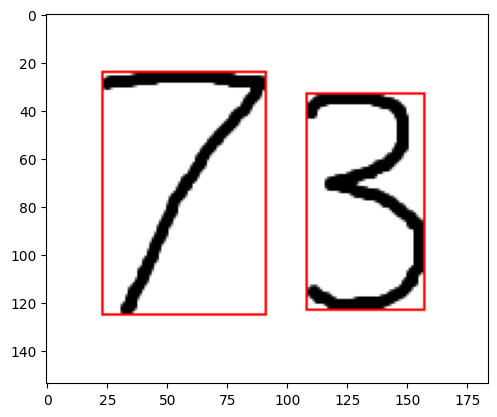

In [16]:
img_copy = image.copy()
for (x,y), w,h in rect:
  cv2.rectangle(img_copy,(x,y),(x+w,y+h), (255,0,0), 1)

plt.imshow(img_copy)

# MNIST Dataset

In [17]:
from keras.datasets import mnist
from keras.utils.np_utils import to_categorical

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Ubah ke one hot encoding
y_cat_test = to_categorical(y_test,10)
y_cat_train = to_categorical(y_train,10)

# Normalisasi
x_train = x_train/255
x_test = x_test/255

# Reshape data
x_train = x_train.reshape(60000, 28, 28, 1)
x_test = x_test.reshape(10000,28,28,1)

11490434/11490434 [==============================] - 0s 0us/step


## Training model

In [19]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten

In [20]:
model = Sequential()

# CONVOLUTIONAL LAYER
model.add(Conv2D(filters=32, kernel_size=(4,4),input_shape=(28, 28, 1), activation='relu',))
# POOLING LAYER
model.add(MaxPool2D(pool_size=(2, 2)))

# FLATTEN IMAGES FROM 28 by 28 to 764 BEFORE FINAL LAYER
model.add(Flatten())

# 128 NEURONS IN DENSE HIDDEN LAYER (YOU CAN CHANGE THIS NUMBER OF NEURONS)
model.add(Dense(128, activation='relu'))

# LAST LAYER IS THE CLASSIFIER, THUS 10 POSSIBLE CLASSES
model.add(Dense(10, activation='softmax'))


model.compile(loss='categorical_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 25, 25, 32)        544       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 12, 12, 32)       0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 4608)              0         
                                                                 
 dense (Dense)               (None, 128)               589952    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 591,786
Trainable params: 591,786
Non-trainable params: 0
__________________________________________________

In [21]:
# Training data
model.fit(x_train,y_cat_train,epochs=3)

Epoch 1/3
1875/1875 [==============================] - 47s 25ms/step - loss: 0.1382 - accuracy: 0.9583
Epoch 2/3
1875/1875 [==============================] - 47s 25ms/step - loss: 0.0460 - accuracy: 0.9865
Epoch 3/3
1875/1875 [==============================] - 45s 24ms/step - loss: 0.0312 - accuracy: 0.9906


In [23]:
# Test the model
predict = model.predict(x_test)
classes = np.argmax(predict,axis=1)

313/313 [==============================] - 2s 7ms/step


In [59]:
x_test.shape

(10000, 28, 28, 1)

In [29]:
predict[11]

array([6.2942433e-08, 1.1040540e-12, 4.7236444e-13, 3.8240255e-13,
       1.1239243e-12, 4.6882401e-11, 9.9999982e-01, 9.0514587e-16,
       6.0529354e-10, 2.9667414e-13], dtype=float32)

In [30]:
classes[11]

6

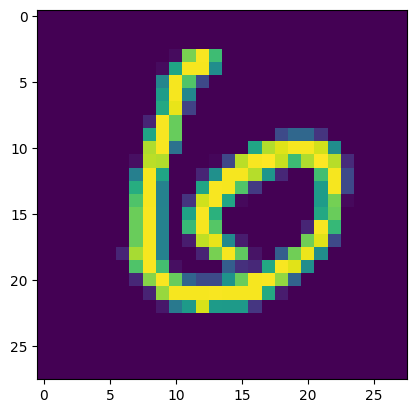

In [31]:
plt.imshow(x_test[11])

In [110]:
x_test

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

# OCR

In [90]:
# Load data
data_image = 'digit.jpg'
image = cv2.imread(data_image)

# Get get_rect
rect = get_rect(image)

# Detect number


number of numbers on image :  8


155

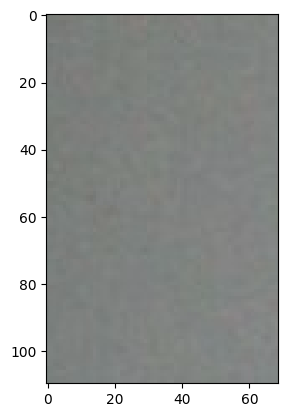

In [119]:
# Test padding
copy = image.copy()

number = copy[y-10:y+h+10, x-10:x+w+10]
plt.imshow(number)
copy.max()

In [115]:
def detect_number(rect, image):
  # Setiap rectangle yang ada, kita lakukan model.predict()

  # Get the ROI
  rois = []
  for (x,y),w,h in rect:
    padding = 10
    roi = image[y-padding:y+h+padding, x-padding:x+w+padding]
    roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    roi = cv2.resize(roi, (28,28))
    # roi = roi/ 255
    roi = np.reshape(roi, (28,28,1))
    print(roi.shape)
    rois.append(roi)
    # plt.imshow(roi)
    # model.predict(roi)
  return rois
x_ocr = detect_number(rect, image)

(28, 28, 1)
(28, 28, 1)
(28, 28, 1)
(28, 28, 1)
(28, 28, 1)
(28, 28, 1)
(28, 28, 1)
(28, 28, 1)


In [98]:
new_x = np.asarray(x_ocr)

In [93]:
new_x.shape

(8, 28, 28, 1)

In [105]:
predicted  = model.predict(new_x)

1/1 [==============================] - 0s 27ms/step


In [95]:
classes = np.argmax(predict,axis=1)

In [106]:
predicted

array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.7649205e-11,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        9.9999994e-01, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        9.9999994e-01, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        9.9999994e-01, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        9.9999994e-01, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        9.9999994e-01, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 9.9999994e-01,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.00

In [97]:
classes[0]

8

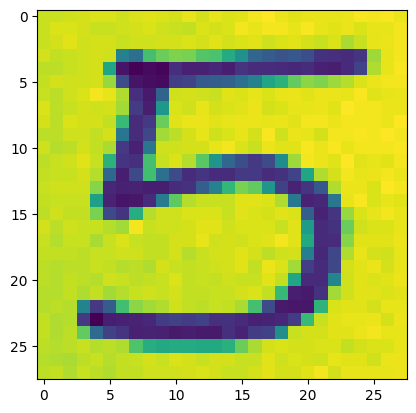

In [102]:
plt.imshow(x_ocr[5])

In [114]:
x_ocr[5].max()

0.5529411764705883

## Combine them all

In [141]:
def detect_number(rect, image):
  # Setiap rectangle yang ada, kita lakukan model.predict()

  # Get the ROI
  rois = []
  for (x,y),w,h in rect:
    padding = 10
    roi = image[y-padding:y+h+padding, x-padding:x+w+padding]
    roi = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    roi = cv2.bitwise_not(roi)
    roi = roi/ roi.max()
    roi = cv2.resize(roi, (28,28))
    roi = np.reshape(roi, (28,28,1))
    rois.append(roi)
    # plt.imshow(roi)
    # model.predict(roi)
  return rois

In [151]:
# Load data
data_image = 'Screenshot 2023-05-29 105948.png'
image = cv2.imread(data_image)

# Get get_rect
rect = get_rect(image)

# Format data number
x_ocr = detect_number(rect, image)
new_x = np.asarray(x_ocr)

# Predict
predicted  = model.predict(new_x)
classes = np.argmax(predicted,axis=1)

print(classes)

number of numbers on image :  3
1.0
1.0
1.0
1/1 [==============================] - 0s 27ms/step
[3 5 5]


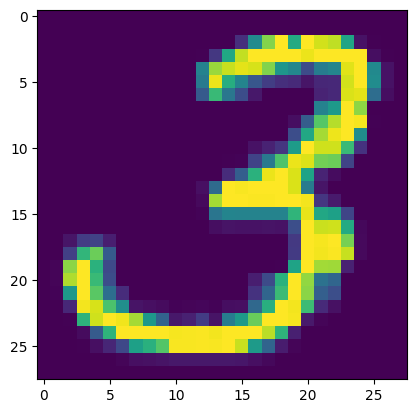

In [152]:
plt.imshow(new_x[0])
